In [32]:
#######################     LIBRARIES     ##########################
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
import sys
from multifidelity_NN_functions import compute_randomized_SVD, sliding_windows, getOpti, reshape_lstm, create_model, train_model, load_model, save_model, load_reaction_diffusion
import pickle
import os
import tensorflow as tf
import keras.backend as K
from tensorflow.keras.models import model_from_json
import mat73
import scipy.io
from module_utils import * 

from scipy.interpolate import griddata
sys.path.append('../utils')

from Structure import *

seed = 7

train = False
scaling = True
save = False
small_data = True

path = './data/reaction_diffusion/'

In [33]:
#########################   DATA     ##########################
#Time
tlf_0 = 0.
thf_0 = 0.
Tlf = 80. 
Thf = 40.
dt = 0.05

#Parameters
mu_0 = 0.5
mu_1 = 1.5

N_mu_train = 10
mu_train = np.linspace(mu_0, mu_1, N_mu_train, endpoint = True)

if small_data:
    N_mu_test = 2
    mu_test = np.array([0.875, 1.375])
else:
    N_mu_test = 25
    mu_test = np.linspace(mu_0, mu_1, N_mu_test, endpoint = True)
    
#Load data train
u_lf, x_LF, t_lf = load_reaction_diffusion(mu_train, 'LF', path = path + 'train/')
u_hf, x_HF, t_hf = load_reaction_diffusion(mu_train, 'HF', path = path + 'train/')

Nx_lf, Ny_lf, Nt_lf_train, N_mu_train = u_lf.shape
Nx_hf, Ny_hf, Nt_hf_train, N_mu_train = u_hf.shape

#Load data test
u_lf_test, _, t_lf_test = load_reaction_diffusion(mu_test, 'LF', path = path + 'test/')
u_hf_test, _, t_hf_test = load_reaction_diffusion(mu_test, 'HF', path = path + 'test/', splitted = True)

Nx_lf, Ny_lf, Nt_lf_test, N_mu_test = u_lf_test.shape
Nx_hf, Ny_hf, Nt_hf_test, N_mu_test = u_hf_test.shape

#Same time frequency for LF and HF in this example
Nt_train = Nt_lf_train = Nt_hf_train
Nt_test  = Nt_lf_test  = Nt_hf_test

In [34]:
#########################   INTERPOLATION     ##########################
coord_x_LF, coord_y_LF = np.meshgrid(x_LF, x_LF)
coord_LF = np.stack((coord_x_LF, coord_y_LF), axis = 2).reshape(-1,2)

coord_x_HF, coord_y_HF = np.meshgrid(x_HF, x_HF)
coord_HF = np.stack((coord_x_HF, coord_y_HF), axis = 2).reshape(-1,2)

#Interpolate LF data at the HF dofs
u_lf = griddata(coord_LF, u_lf.reshape(-1, Nt_train, N_mu_train), coord_HF, method='nearest').reshape(Nx_hf, Ny_hf, Nt_train, N_mu_train)
u_lf_test = griddata(coord_LF, u_lf_test.reshape(-1, Nt_lf_test, N_mu_test), coord_HF, method='nearest').reshape(Nx_hf, Ny_hf, Nt_lf_test, N_mu_test)

N = Nx_hf*Ny_hf #total number of HF dofs

In [35]:
u_lf.shape

(100, 100, 801, 10)

<>:17: SyntaxWarning: invalid escape sequence '\m'
<>:30: SyntaxWarning: invalid escape sequence '\m'
<>:17: SyntaxWarning: invalid escape sequence '\m'
<>:30: SyntaxWarning: invalid escape sequence '\m'
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_225908\3611569960.py:17: SyntaxWarning: invalid escape sequence '\m'
  plt.title('Low-fidelity \n $\mu = $' + str(round(mu_train[idx_mu],2)) + ', $t= $' + str(round(t_lf[-1])) , fontsize = 22)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_225908\3611569960.py:30: SyntaxWarning: invalid escape sequence '\m'
  plt.title('High-fidelity \n $\mu = $' + str(round(mu_train[idx_mu],2)) + ', $t= $' + str(round(t_lf[-1])) , fontsize = 22)


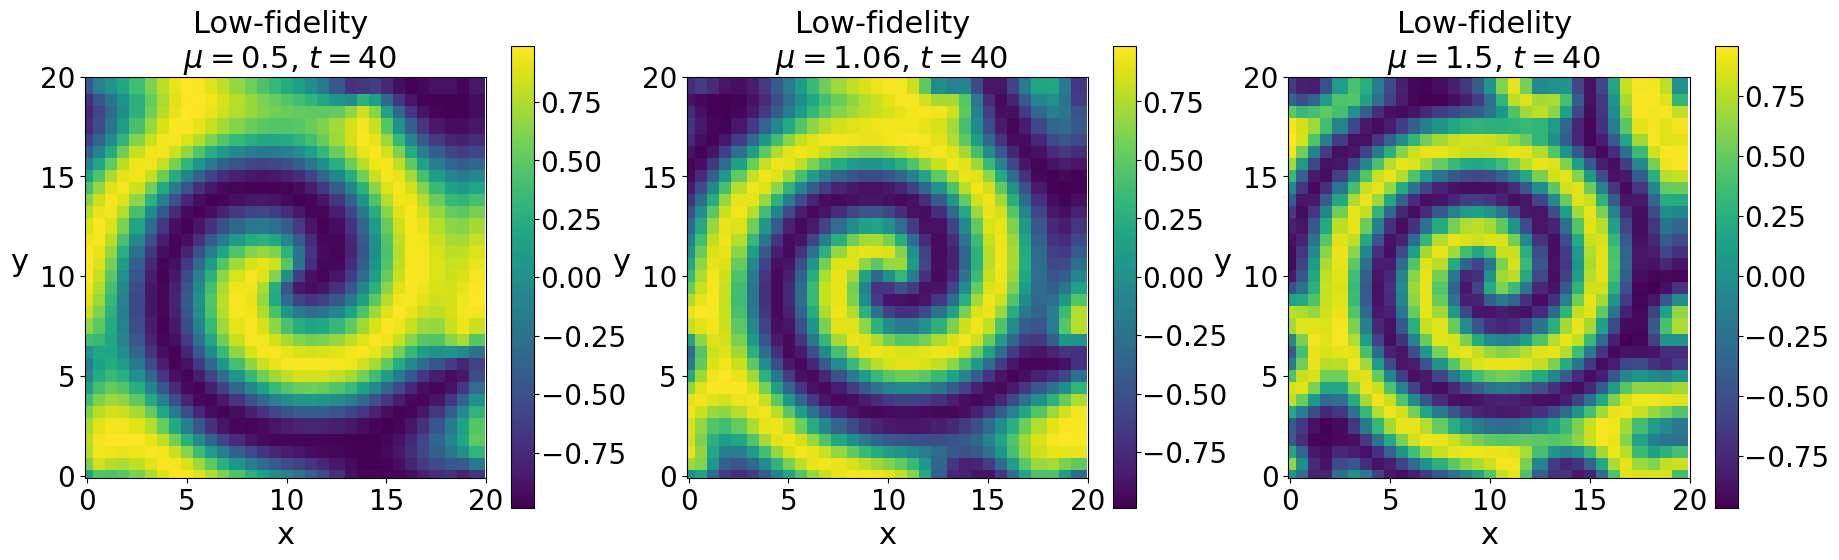

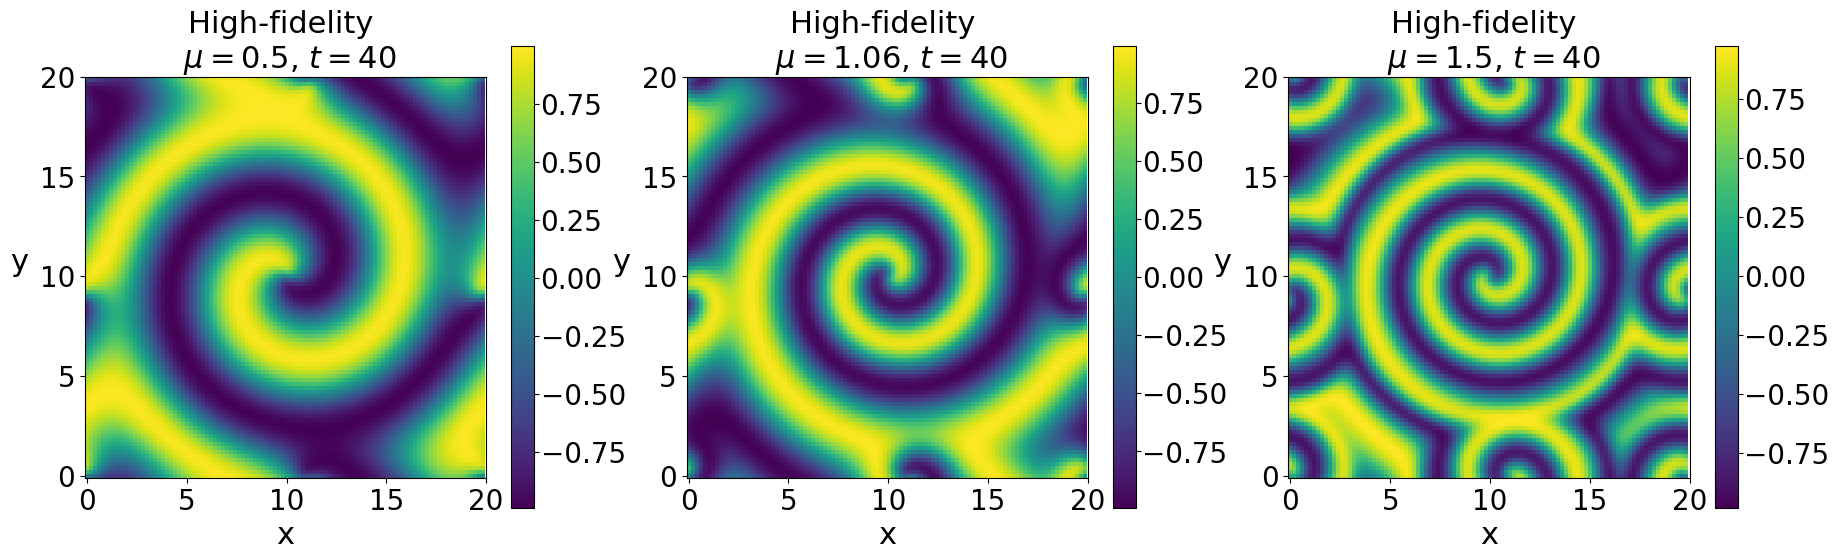

In [36]:
#########################   Visualize train data     ##########################
#########################         LF VS HF          ###########################

loc = np.arange(0,Nx_hf+1,int(Nx_hf/4))
tick = np.arange(0,21,5)

#Low-fidelity training data
fig = plt.figure(figsize=(22,6))
idx_mu_list = [0, int(N_mu_train/2), -1]
for i,idx_mu in enumerate(idx_mu_list):
    ax = fig.add_subplot(131 + i)
    surf = ax.imshow(u_lf[:,:,-1,idx_mu], origin = 'lower')
    plt.xticks(loc, tick,fontsize=20)
    plt.yticks(loc, tick,fontsize=20)
    plt.xlabel('x', rotation = 0,fontsize = 22)
    plt.ylabel('y', rotation = 0, fontsize = 22, labelpad=15)
    plt.title('Low-fidelity \n $\mu = $' + str(round(mu_train[idx_mu],2)) + ', $t= $' + str(round(t_lf[-1])) , fontsize = 22)
    cbar = plt.colorbar(surf)
    cbar.ax.tick_params(labelsize=20,pad=1)
    
#High-fidelity training data
fig = plt.figure(figsize=(22,6))
for i,idx_mu in enumerate(idx_mu_list):
    ax = fig.add_subplot(131 + i)
    surf = ax.imshow(u_hf[:,:,-1,idx_mu], origin = 'lower')
    plt.xticks(loc, tick,fontsize=20)
    plt.yticks(loc, tick,fontsize=20)
    plt.xlabel('x', rotation = 0,fontsize = 22)
    plt.ylabel('y', rotation = 0, fontsize = 22, labelpad=15)
    plt.title('High-fidelity \n $\mu = $' + str(round(mu_train[idx_mu],2)) + ', $t= $' + str(round(t_lf[-1])) , fontsize = 22)
    cbar = plt.colorbar(surf)
    cbar.ax.tick_params(labelsize=20,pad=1)

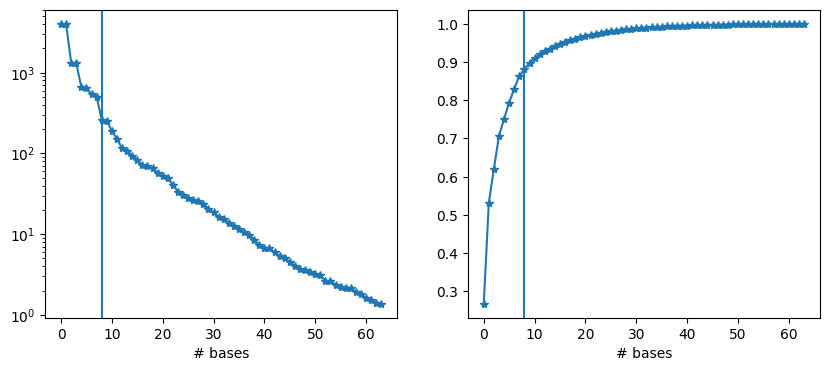

In [37]:
#########################   Proper Orthogonal Decomposition (POD)   ##########################
n_POD_large = 64 # we consider first a larger basis

#Reshape for POD
u_hf_pod = np.reshape(u_hf, (N, Nt_train*N_mu_train), 'F')

#POD on HF training data
POM_u, S_u = compute_randomized_SVD(u_hf_pod, n_POD_large, N, 1)

#We restrict the POD basis to the first 9 POD modes
n_POD = 9

plt.figure(figsize = (10,4))
plt.subplot(121)
plt.plot(S_u,'*-')
plt.axvline(x = n_POD-1)
plt.yscale('log')
plt.xlabel('# bases')

plt.subplot(122)
plt.plot(np.cumsum(S_u)/np.sum(S_u),'*-')
plt.axvline(x = n_POD-1)
plt.xlabel('# bases')
plt.show()

POM_u = POM_u[:,:n_POD]
S_u = S_u[:n_POD]

In [38]:
S_u.shape

(9,)

In [19]:
POM_u.shape

(10000, 9)

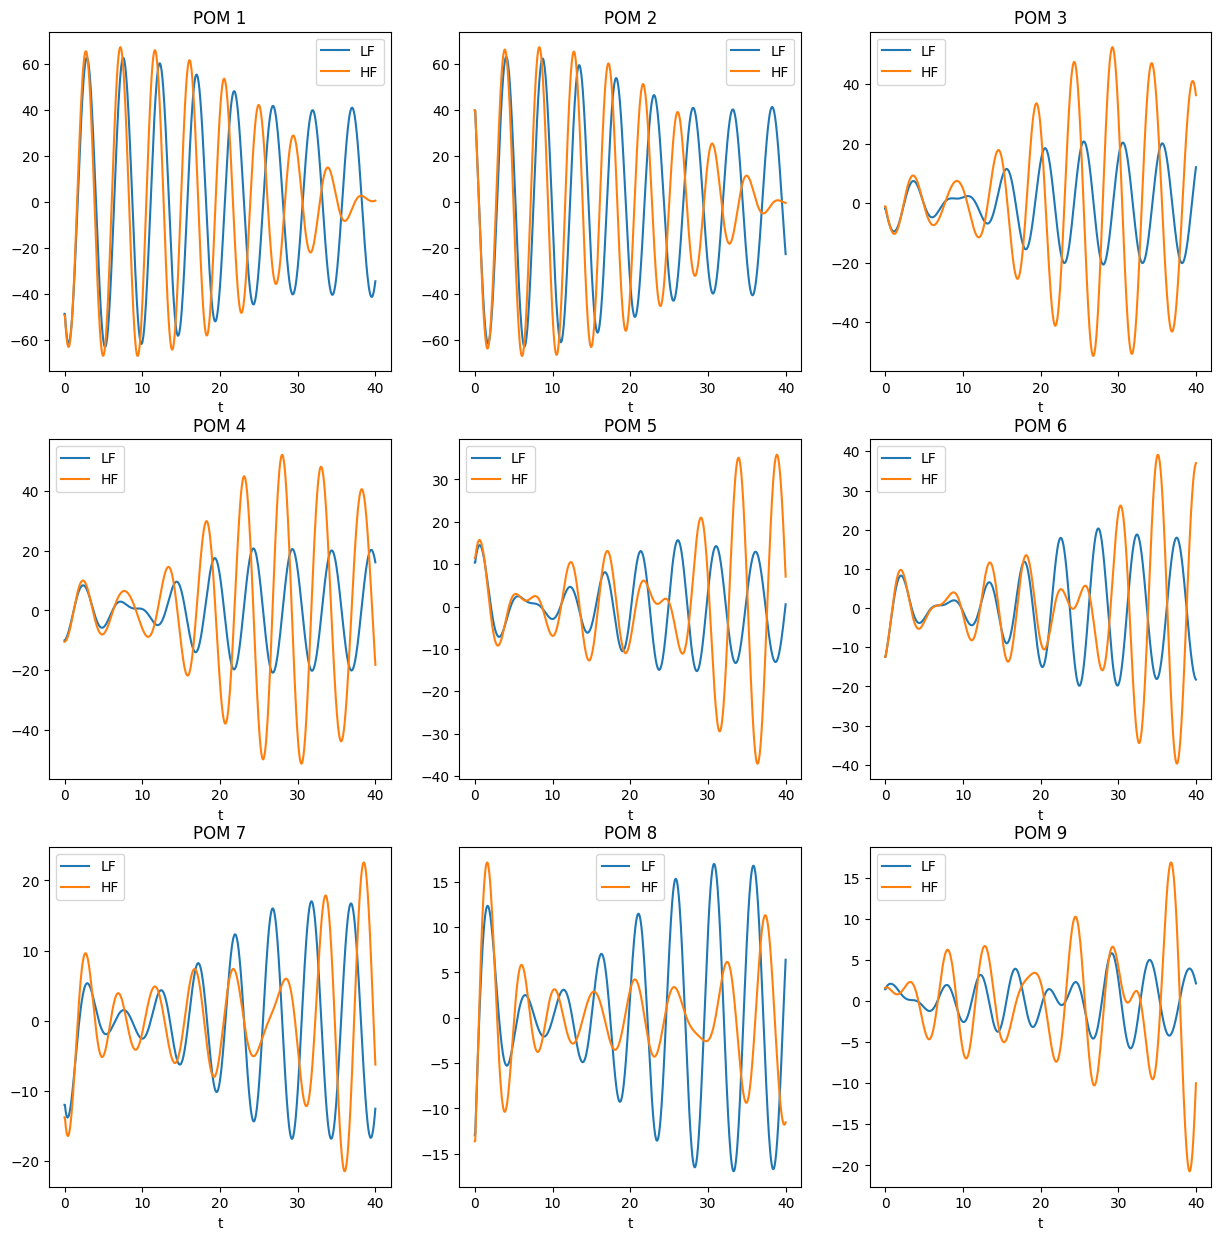

In [6]:
#########################   PROJECTION ONTO POD BASIS    ##########################
u_lf_pod = np.reshape(u_lf, (N, Nt_train*N_mu_train), 'F')
u_lf_test_pod = np.reshape(u_lf_test, (N, Nt_lf_test*N_mu_test), 'F')
u_hf_test_pod = np.reshape(u_hf_test, (N, Nt_test*N_mu_test), 'F')

ulf_train = u_lf_pod.T @ POM_u
uhf_train = u_hf_pod.T @ POM_u
ulf_test = u_lf_test_pod.T @ POM_u
uhf_test = u_hf_test_pod.T @ POM_u

#Reshape to make data suitable to LSTM network
ulf_train = np.reshape(ulf_train, (N_mu_train, Nt_train, -1))
uhf_train = np.reshape(uhf_train, (N_mu_train, Nt_train, -1))
ulf_test = np.reshape(ulf_test, (N_mu_test, Nt_lf_test, -1))
uhf_test = np.reshape(uhf_test, (N_mu_test, Nt_test, -1))

#Plot POD coefficients: LF vs HF
fig = plt.figure(figsize=(15,15))
for i in range(9):
    ax = fig.add_subplot(331 + i)
    plt.plot(t_lf, ulf_train[-1,:,i], label = 'LF')
    plt.plot(t_hf, uhf_train[-1, :, i], label = 'HF')
    ax.title.set_text('POM ' + str(i+1))
    plt.xlabel('t')
    plt.legend()
plt.show()

In [8]:
#########################   LSTM NN PREPROCESS    ##########################
#Scaling
if scaling:
    scale = np.max(ulf_train) 
    scale_param = 1.
else:
    scale =  1.
    scale_param = 1.
    
#train
t_train_lstm = np.tile(t_lf, N_mu_train).T.reshape(N_mu_train,-1,1)
mu_train_lstm = np.repeat(mu_train, Nt_train).reshape(N_mu_train,-1,1) / scale_param
ulf_train_lstm = ulf_train / scale
uhf_train_lstm = uhf_train / scale

#test
t_test_lstm = np.tile(t_hf_test, N_mu_test).T.reshape(N_mu_test,-1,1)
mu_test_lstm = np.repeat(mu_test, Nt_test).reshape(N_mu_test,-1,1) / scale_param
ulf_test_lstm = ulf_test / scale
uhf_test_lstm = uhf_test / scale

#Multi-fidelity network input
#concatenate in a single input: (time, param, LF data)
train_mf_lstm = np.concatenate((t_train_lstm, mu_train_lstm, ulf_train_lstm), axis=2)
test_mf_lstm = np.concatenate((t_test_lstm, mu_test_lstm, ulf_test_lstm), axis=2)

In [28]:
ulf_train_lstm.shape

(10, 801, 9)

In [25]:
mu_train_lstm.shape

(10, 801, 1)

In [29]:
t_train_lstm.shape

(10, 801, 1)

In [31]:
POM_u

array([[ 0.00199297,  0.00149918,  0.00318337, ..., -0.00321052,
         0.01085529,  0.00092033],
       [-0.00034133,  0.00383653,  0.015784  , ...,  0.01150528,
         0.01672845,  0.00279256],
       [-0.00147835,  0.00582868,  0.02281444, ...,  0.01877493,
         0.02161355,  0.0077269 ],
       ...,
       [ 0.00163728, -0.00785728, -0.02429438, ..., -0.02139913,
        -0.02351677, -0.00966692],
       [ 0.00210985, -0.00602308, -0.02245125, ..., -0.01879251,
        -0.0211956 , -0.00570868],
       [ 0.0014792 , -0.00377697, -0.01460769, ..., -0.00985928,
        -0.01823382, -0.00317058]])

In [23]:
t_lf

array([ 0.  ,  0.05,  0.1 ,  0.15,  0.2 ,  0.25,  0.3 ,  0.35,  0.4 ,
        0.45,  0.5 ,  0.55,  0.6 ,  0.65,  0.7 ,  0.75,  0.8 ,  0.85,
        0.9 ,  0.95,  1.  ,  1.05,  1.1 ,  1.15,  1.2 ,  1.25,  1.3 ,
        1.35,  1.4 ,  1.45,  1.5 ,  1.55,  1.6 ,  1.65,  1.7 ,  1.75,
        1.8 ,  1.85,  1.9 ,  1.95,  2.  ,  2.05,  2.1 ,  2.15,  2.2 ,
        2.25,  2.3 ,  2.35,  2.4 ,  2.45,  2.5 ,  2.55,  2.6 ,  2.65,
        2.7 ,  2.75,  2.8 ,  2.85,  2.9 ,  2.95,  3.  ,  3.05,  3.1 ,
        3.15,  3.2 ,  3.25,  3.3 ,  3.35,  3.4 ,  3.45,  3.5 ,  3.55,
        3.6 ,  3.65,  3.7 ,  3.75,  3.8 ,  3.85,  3.9 ,  3.95,  4.  ,
        4.05,  4.1 ,  4.15,  4.2 ,  4.25,  4.3 ,  4.35,  4.4 ,  4.45,
        4.5 ,  4.55,  4.6 ,  4.65,  4.7 ,  4.75,  4.8 ,  4.85,  4.9 ,
        4.95,  5.  ,  5.05,  5.1 ,  5.15,  5.2 ,  5.25,  5.3 ,  5.35,
        5.4 ,  5.45,  5.5 ,  5.55,  5.6 ,  5.65,  5.7 ,  5.75,  5.8 ,
        5.85,  5.9 ,  5.95,  6.  ,  6.05,  6.1 ,  6.15,  6.2 ,  6.25,
        6.3 ,  6.35,

In [15]:
ulf_train.shape

(10, 801, 9)

In [14]:
train_mf_lstm.shape

(10, 801, 11)

In [13]:
ulf_train.shape

(10, 801, 9)

In [49]:
#########################   LSTM NN HYPERPARAMETERS    ##########################
params_MF = {'batch': 37, 
             'lay': 1, 
             'nodes': 69, 
             'lr':  0.009476420915650432, 
             'lay_dense': 0, 
             'nodes_dense': 0, 
             'opt': 'Adamax', 
             'sequence_freq': 7, 
             'sequence_length': 133,
             'epochs':  3000, 
             'patience' : 200, 
             'dropout' : 0.3}

The function training took 3169.2972269058228 seconds.


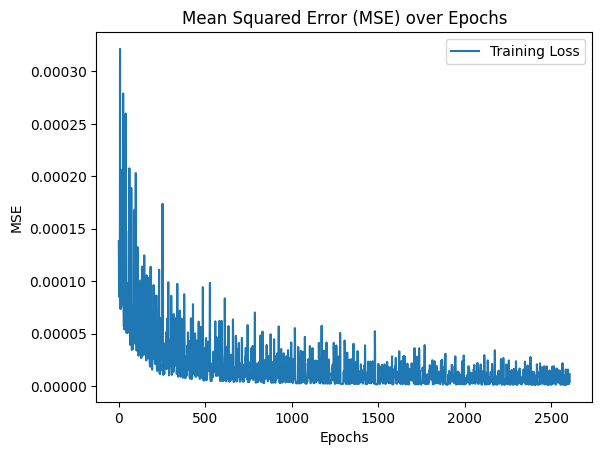

In [50]:
#########################   TRAINING/LOADING    ##########################
model=NetworkFactory.build_network("LSTM", params=params_MF, data_train=train_mf_lstm, output_train=uhf_train_lstm, N=params_MF["epochs"],train=True,do_HPO=False,verbose=True)



In [51]:
#########################   PREDICTION    ##########################
uMF_LSTM_train = model.prediction(train_mf_lstm).reshape(N_mu_train, Nt_train, -1) * scale
uMF_LSTM_test = model.prediction(test_mf_lstm).reshape(N_mu_test, Nt_test, -1) * scale

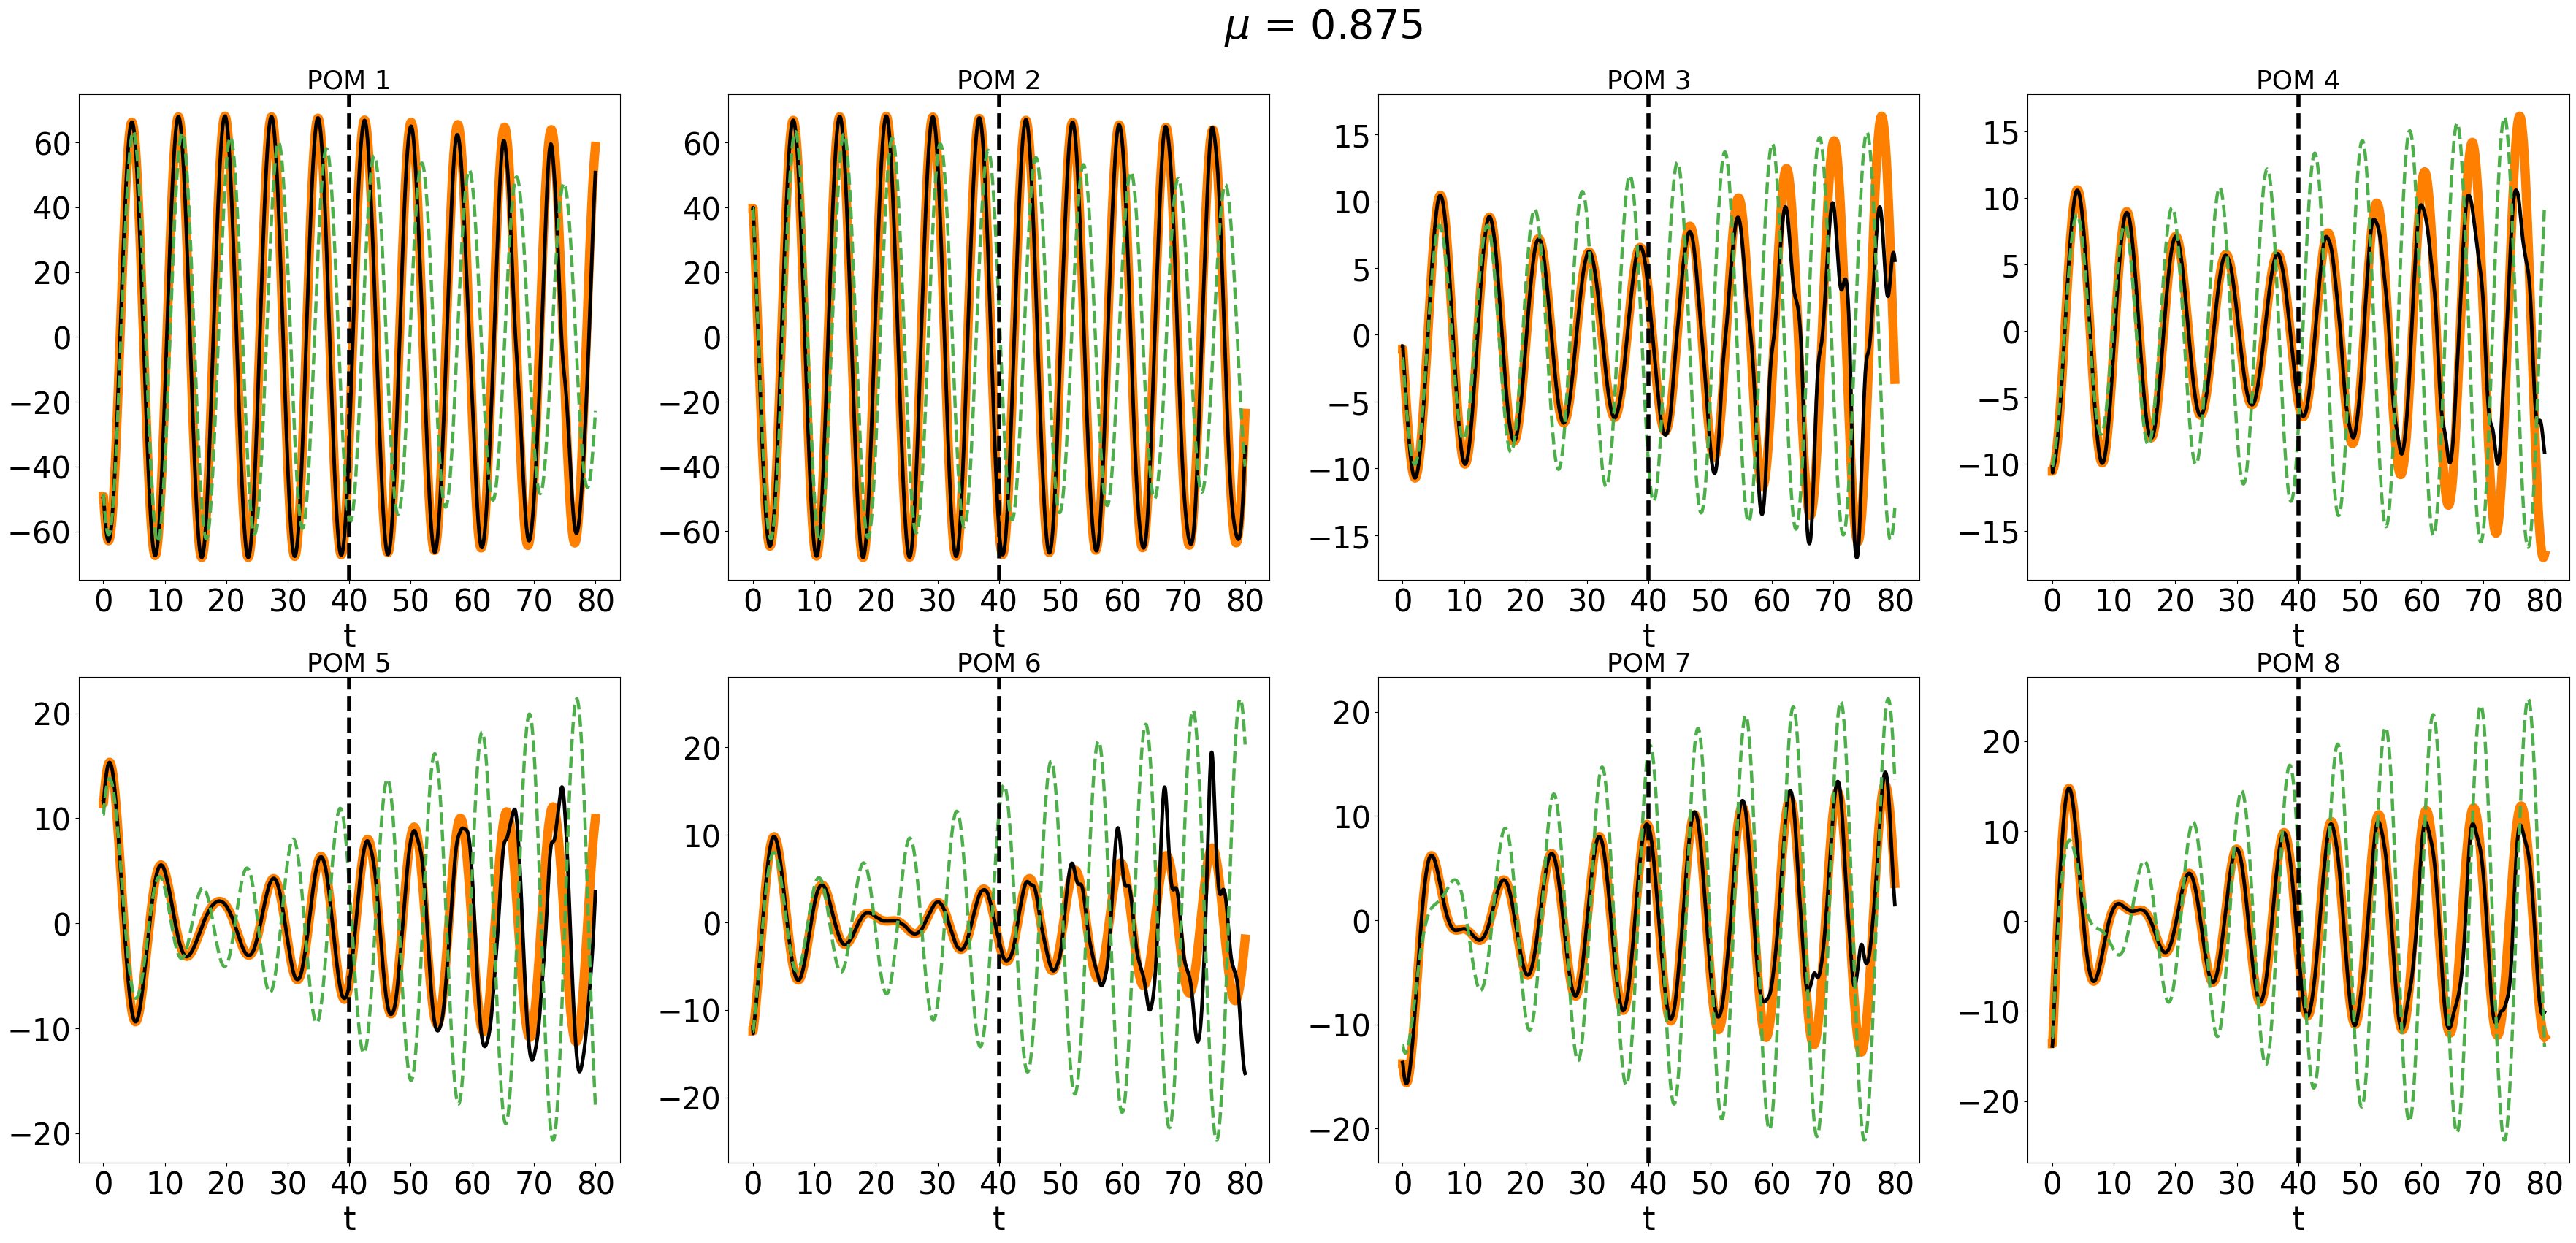

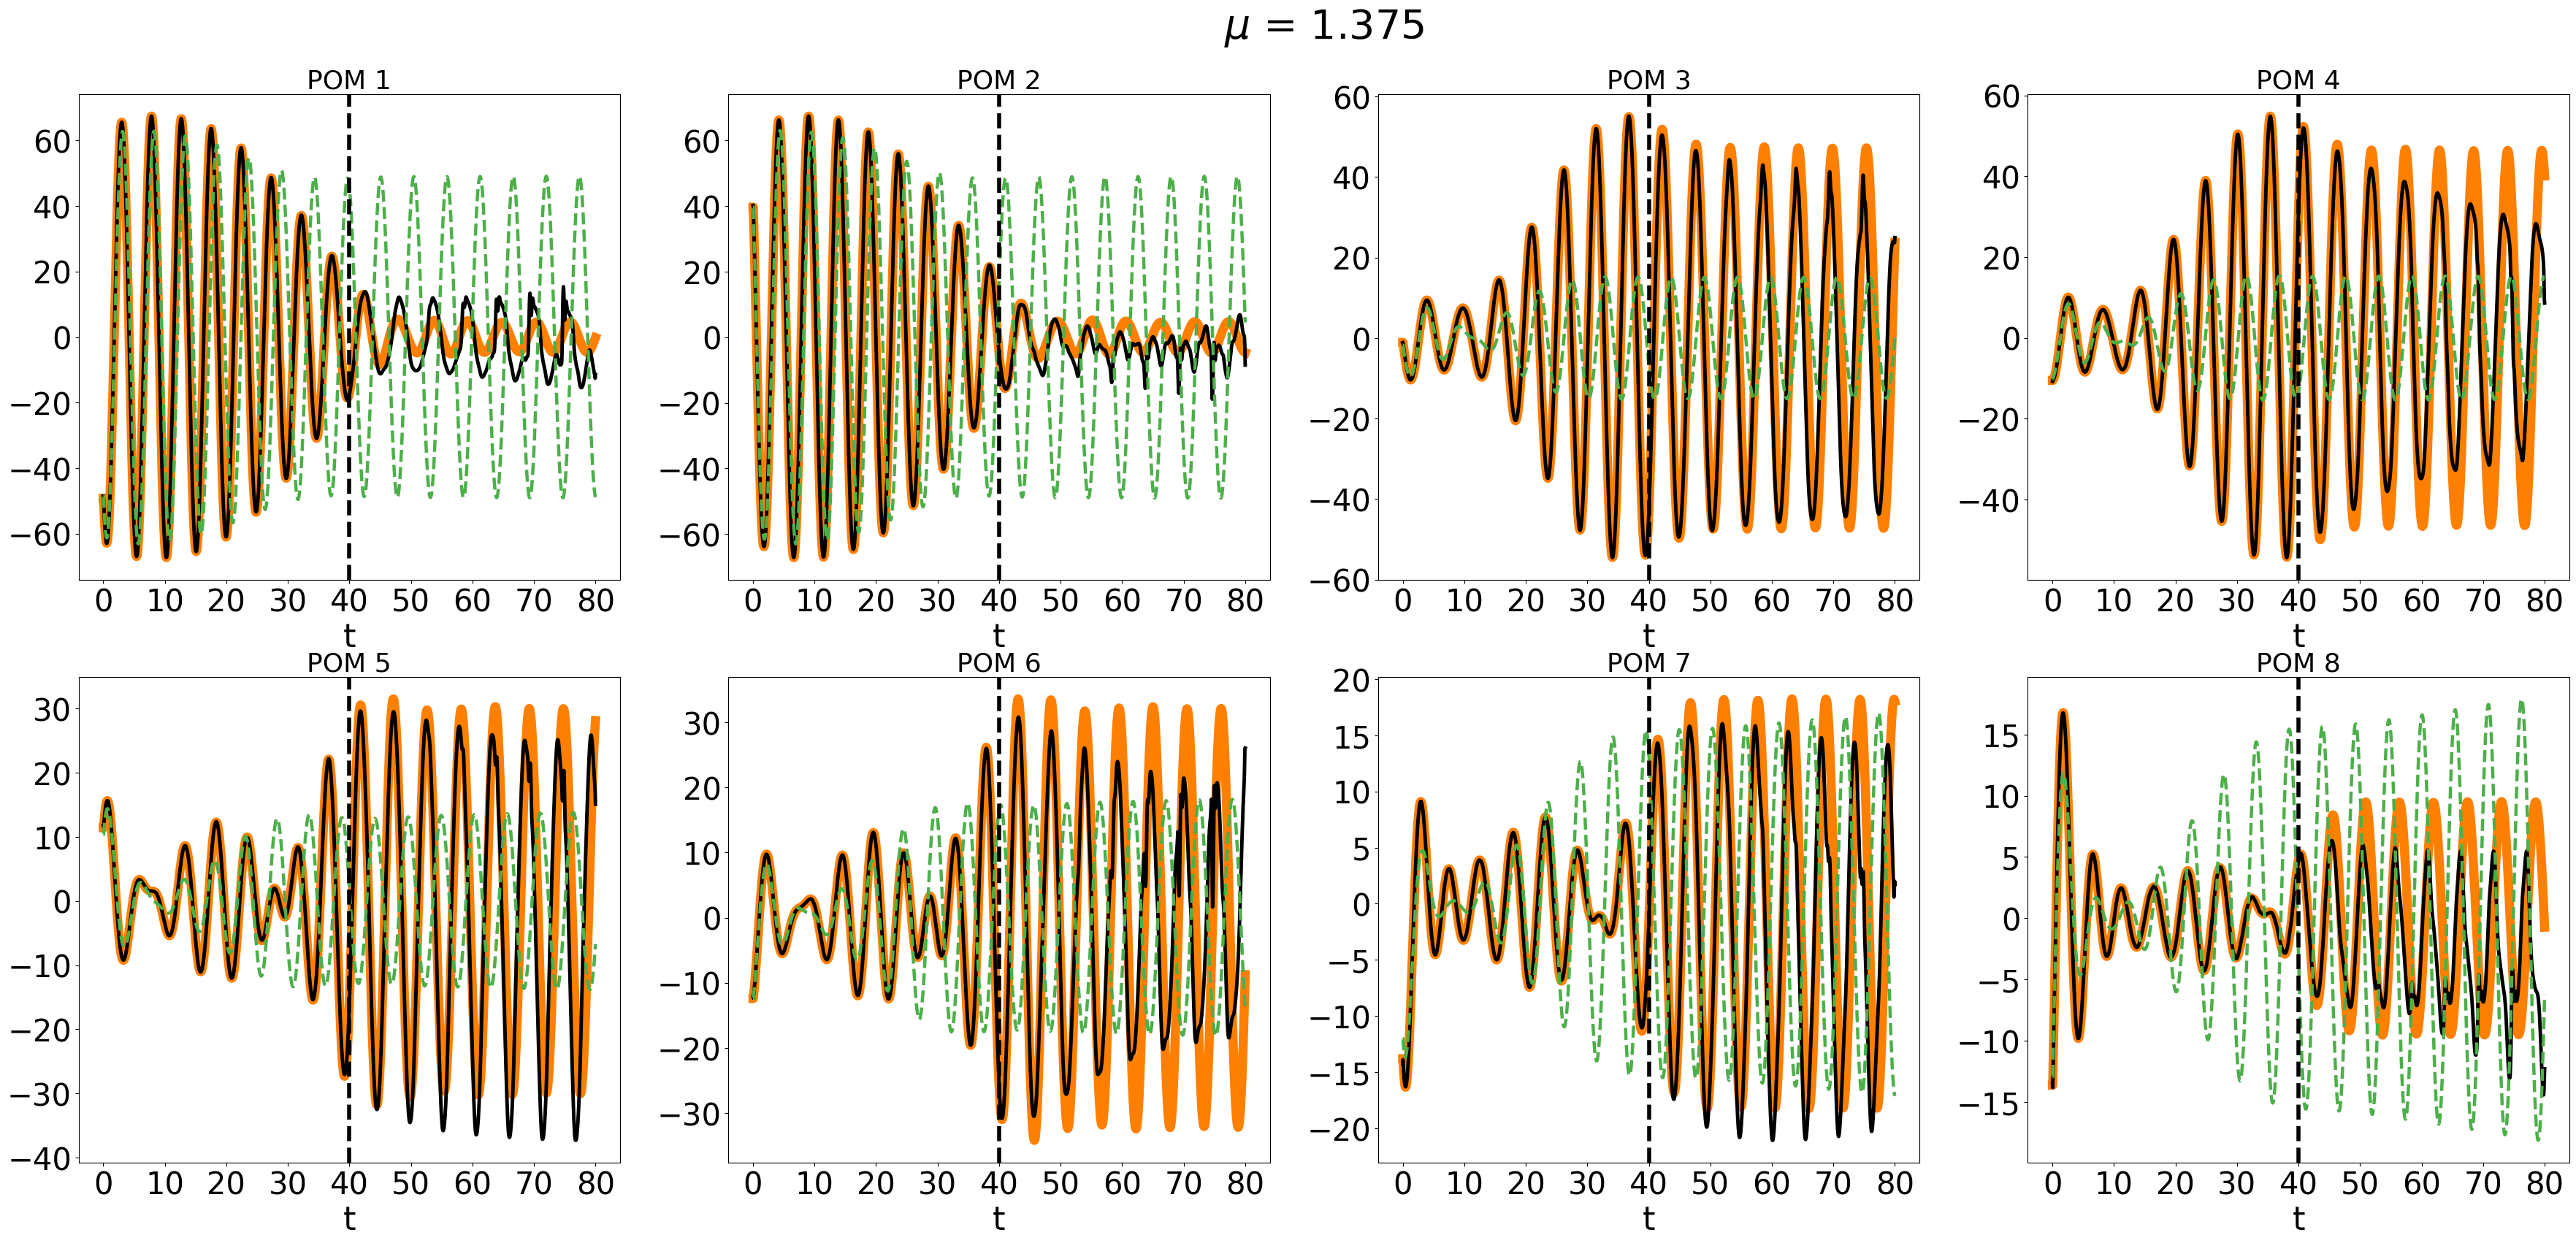

In [52]:
#########################   COMPARISON OF POD MODES    ##########################
if small_data:
    mus = [0,1]
else:
    mus = [9,21]
    
for mu in mus: 
    fig = plt.figure(figsize=(44,19)) 
    plt.title('$\mu$ = ' + str(mu_test[mu].round(3)) + '\n', fontsize = 40)
    plt.axis('off')
    for POD_mode in range(8):
        ax = fig.add_subplot(241 + POD_mode)

        plt.plot(t_hf_test, uhf_test[mu, :, POD_mode],'-', color = '#ff7f00', label = 'HF', linewidth = 9)
        plt.plot(t_hf_test, uMF_LSTM_test[mu, :, POD_mode],'k-', label = 'MF', linewidth = 3.5)
        plt.plot(t_hf_test, ulf_test[mu, :, POD_mode], '--', label = 'LF', color='#4daf4a', linewidth=3.2)

        plt.axvline(x=Thf, linestyle='--', color='black', linewidth = 4)
        ax.set_title('POM ' + str(POD_mode + 1), fontsize = 26)
        plt.xticks(fontsize=30)
        plt.yticks(fontsize=30)
        plt.xlabel('t', rotation=0, fontsize=32)
        #plt.legend(loc = 'lower right', fontsize = 24)
    plt.show()

In [53]:
#########################  POD RECONSTRUCTION    ##########################
uMF_LSTM_train_rec = (uMF_LSTM_train @ POM_u.T).reshape(N_mu_train, Nt_train, Nx_hf, Ny_hf).T
uMF_LSTM_test_rec = (uMF_LSTM_test @ POM_u.T).reshape(N_mu_test, Nt_test, Nx_hf, Ny_hf).T

abs_err_test = np.abs(uMF_LSTM_test_rec - u_hf_test)

In [54]:
t_hf_test

array([0.000e+00, 5.000e-02, 1.000e-01, ..., 7.990e+01, 7.995e+01,
       8.000e+01])

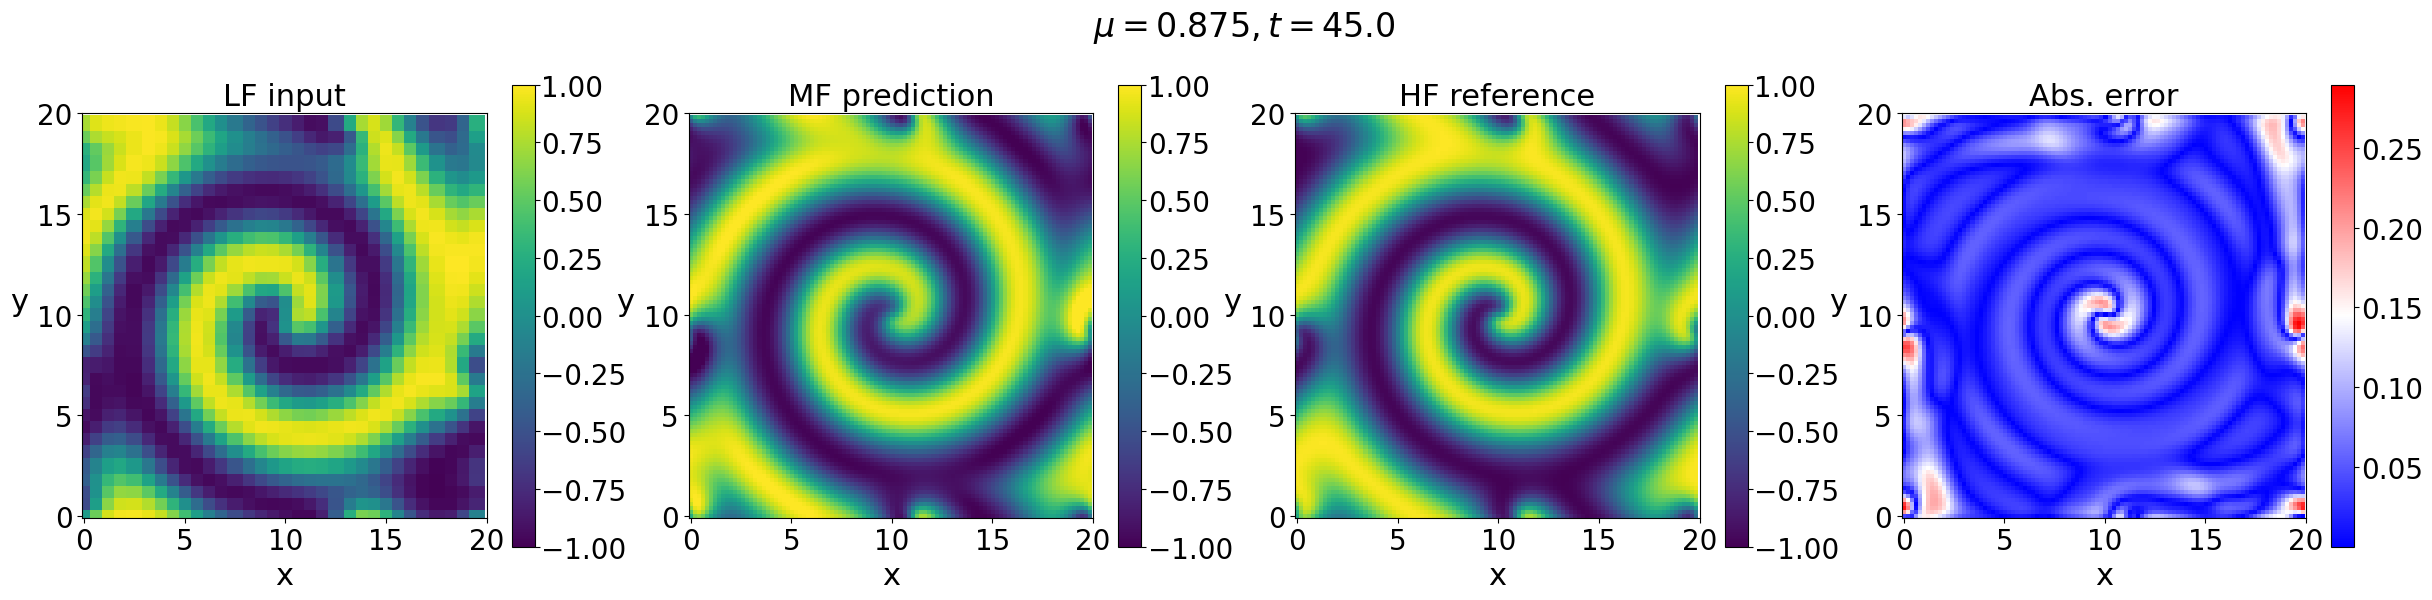

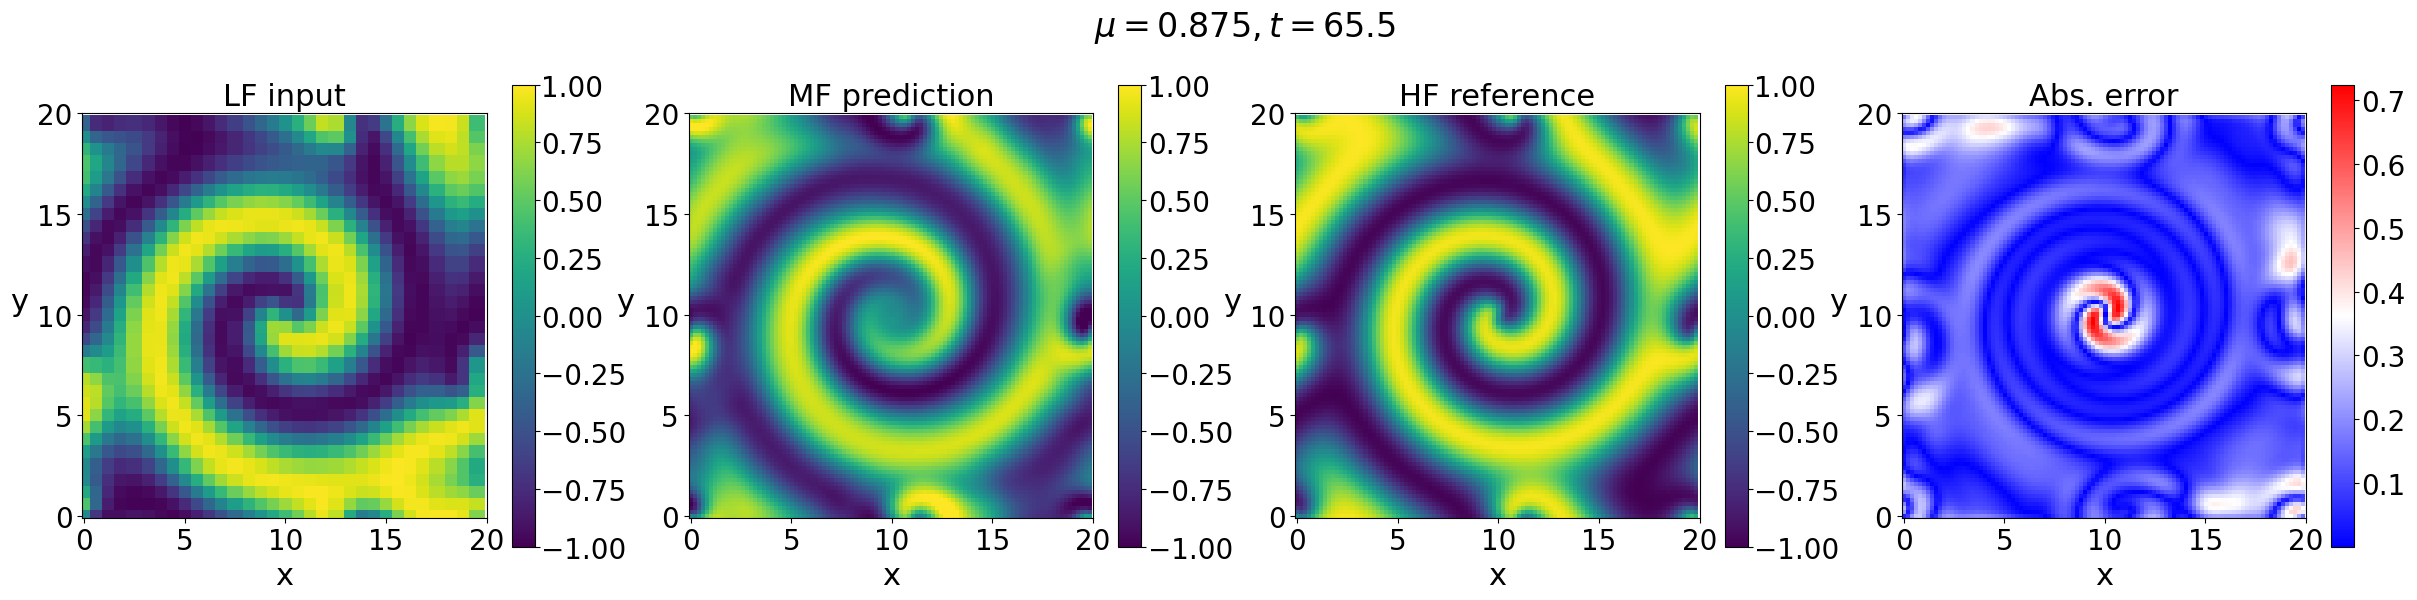

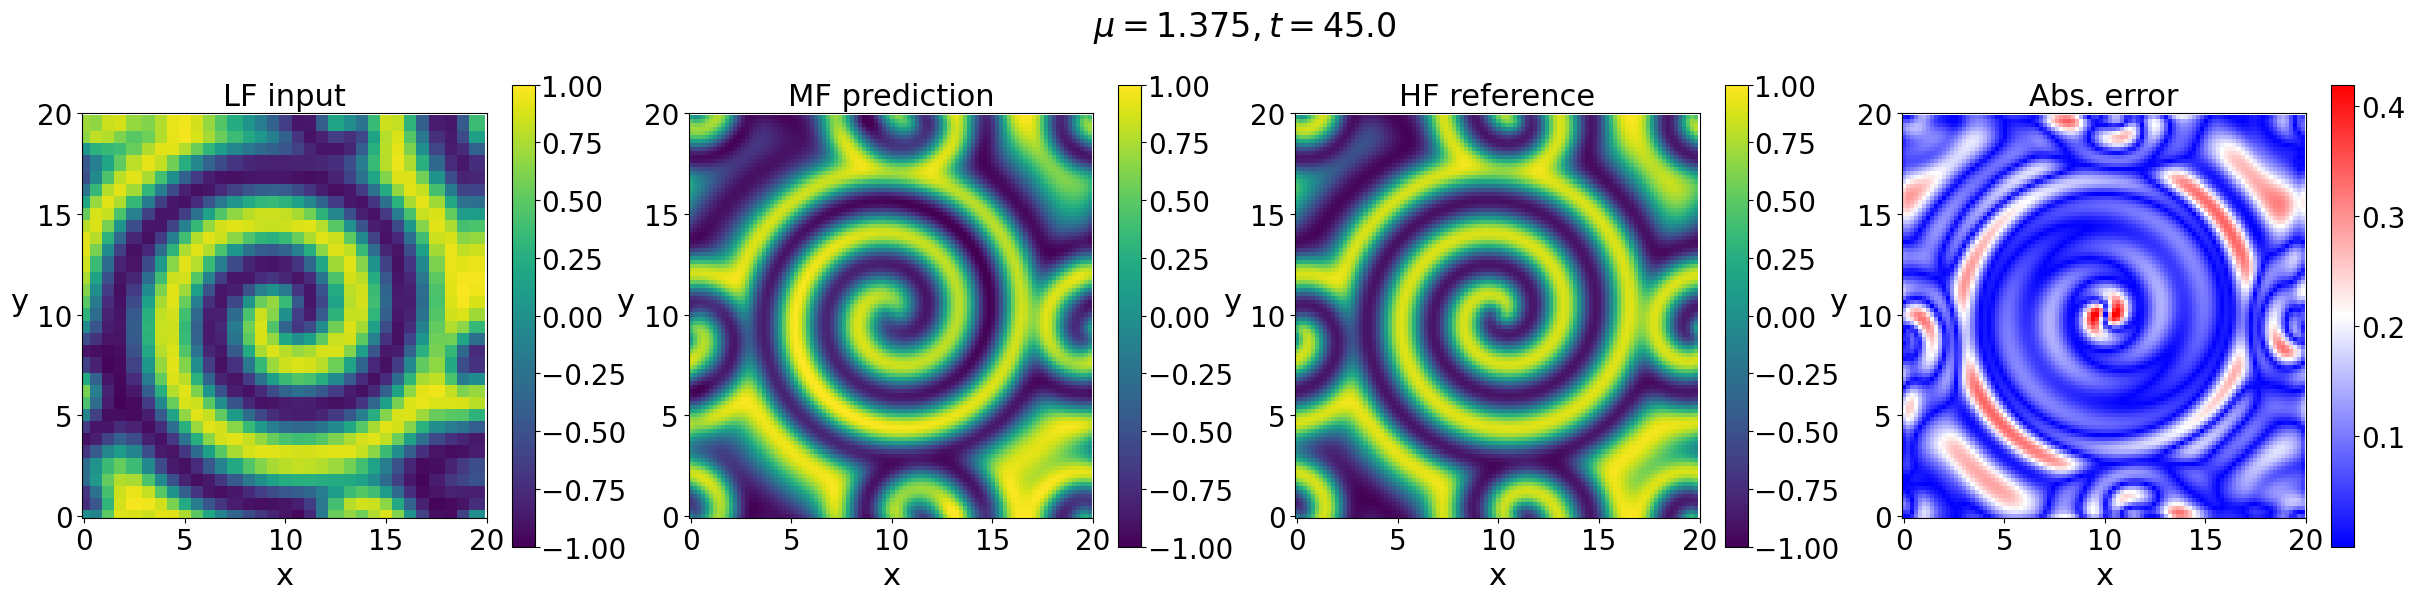

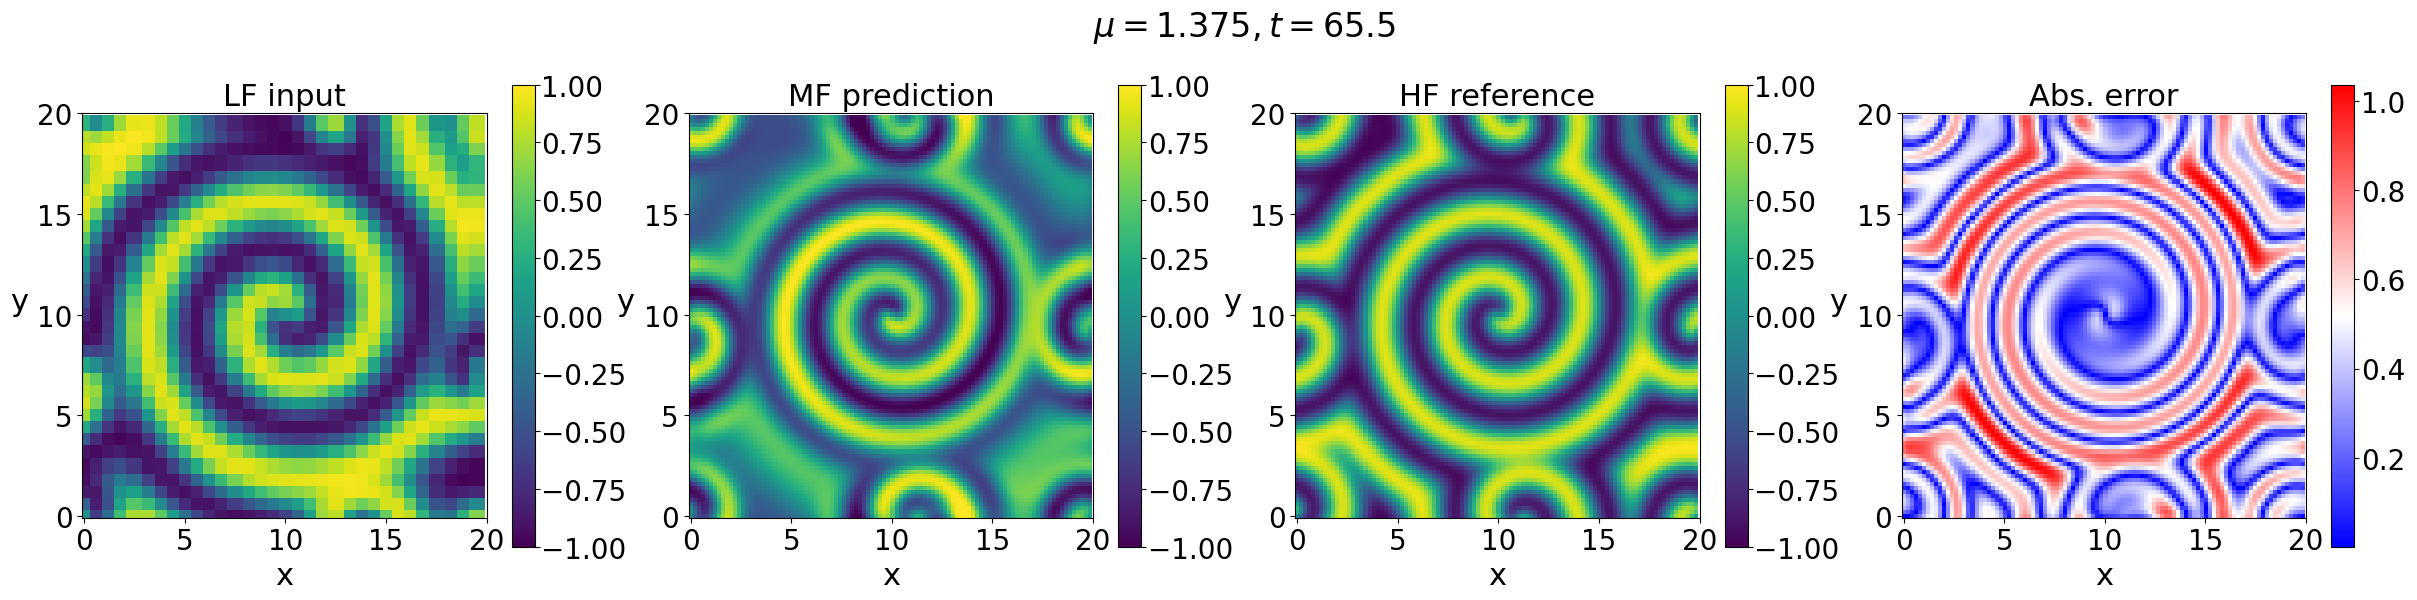

In [55]:
#########################   COMPARISON OF SOLUTION FIELDS     ##########################

if small_data:
    mus = [0,1]
else:
    mus = [9, 21]
times = [45, 65.5]

for mu in mus:
    for time in times:
        fig = plt.figure(figsize=(30,6))
        t = int(time/dt)
        plt.title('$\mu = $' + str(round(mu_test[mu],3)) + '$, t = $' + str(round(t*dt,1)) +'\n' , fontsize = 24)
        plt.axis('off')

        ax = fig.add_subplot(141)
        surf = ax.imshow(u_lf_test[:,:,t,mu], origin = 'lower', vmin=-1, vmax=1)
        plt.xticks(loc, tick,fontsize=20)
        plt.yticks(loc, tick,fontsize=20)
        plt.xlabel('x', rotation = 0,fontsize = 22)
        plt.ylabel('y', rotation = 0, fontsize = 22, labelpad=13)
        title = 'LF input'
        ax.set_title(title, fontsize = 22)
        cbar = plt.colorbar(surf)
        cbar.ax.tick_params(labelsize=20,pad=1)
        
        ax = fig.add_subplot(142)
        surf = ax.imshow(uMF_LSTM_test_rec[:,:,t,mu], origin = 'lower', vmin=-1, vmax=1.)
        plt.xticks(loc, tick,fontsize=20)
        plt.yticks(loc, tick,fontsize=20)
        plt.xlabel('x', rotation = 0,fontsize = 22)
        plt.ylabel('y', rotation = 0, fontsize = 22, labelpad=13)
        title = 'MF prediction' 
        ax.set_title(title, fontsize = 22)
        cbar = plt.colorbar(surf)
        cbar.ax.tick_params(labelsize=20,pad=1)

        ax = fig.add_subplot(143)
        surf = ax.imshow(u_hf_test[:,:,t,mu], origin = 'lower', vmin=-1, vmax=1.)
        plt.xticks(loc, tick,fontsize=20)
        plt.yticks(loc, tick,fontsize=20)
        plt.xlabel('x', rotation = 0,fontsize = 22)
        plt.ylabel('y', rotation = 0, fontsize = 22, labelpad=13)
        title = 'HF reference'  
        ax.set_title(title, fontsize = 22)
        cbar = plt.colorbar(surf)
        cbar.ax.tick_params(labelsize=20,pad=1)
        
        ax = fig.add_subplot(144)
        surf = ax.imshow(abs_err_test[:,:,t,mu], origin = 'lower', cmap='bwr')
        plt.xticks(loc, tick,fontsize=20)
        plt.yticks(loc, tick,fontsize=20)
        plt.xlabel('x', rotation = 0,fontsize = 22)
        plt.ylabel('y', rotation = 0, fontsize = 22, labelpad=13)
        title = 'Abs. error' 
        ax.set_title(title, fontsize = 22)
        cbar = plt.colorbar(surf)
        cbar.ax.tick_params(labelsize=20,pad=1)
        plt.show()

In [56]:
#########################   CREATE VIDEO    ##########################
from celluloid import Camera
from matplotlib.animation import PillowWriter
from IPython.display import HTML

fig, ax = plt.subplots(1, 4, figsize=(16, 4.5))

camera = Camera(fig)
mu = mus[0]
for i in range(0, 1600, 5):
    surf = ax[0].imshow(u_lf_test[:, :, i, mu], vmin=-1, vmax=1)
    surf = ax[1].imshow(uMF_LSTM_test_rec[:, :, i, mu], vmin=-1, vmax=1)
    surf = ax[2].imshow(u_hf_test[:, :, i, mu], vmin=-1, vmax=1)
    surf = ax[3].imshow(np.abs(uMF_LSTM_test_rec[:, :, i, mu] - u_hf_test[:, :, i, mu]),cmap='bwr')
    
    ax[0].set_title("LF input", fontsize = 20)
    ax[1].set_title("MF-POD pred.", fontsize = 20)
    ax[2].set_title("HF reference", fontsize = 20)
    ax[3].set_title("Abs. error", fontsize = 20)
    
    camera.snap()
fig.suptitle("$\mu$ = " + str(round(mu_test[mu],3)), fontsize = 22)
animation = camera.animate()

# Close the figure to prevent it from being displayed
plt.close(fig)

# Save the animation as a GIF using PillowWriter
name = "./results/test_HF_" + str(round(mu_test[mu],3)) + ".gif"
animation.save(name, writer=PillowWriter(fps=10))

# Display the saved GIF
HTML("<img src='" + name + "'>")

# BIP

In [57]:
# potrebbero andare in utils
def process_data(datahf, parameters, t_eval, Yhf):
    # """
    # Find the elements of a dataset nearest to the ones given
    # """
    mask = datahf[:,:,1] == parameters
    datahf_values=datahf[mask]
    datahf_values=np.expand_dims(datahf_values, axis=0)

    t_eval_values = t_eval[:, 0]  # Simplify t_eval to a 1D array if not already
    t_eval_values = t_eval_values[np.newaxis, :]

    # Extract the first dimension slice (:, :, 0) from the original matrix
    slice_0 = datahf_values[0, :, 0]

    # Compute the absolute differences in a vectorized manner
    # The result will be of shape (151, 50)
    differences = np.abs(slice_0[:, np.newaxis] - t_eval_values[0, np.newaxis, :])

    # Find the indices of the minimum values along axis 0
    indices = np.argmin(differences, axis=0)

    # Use the indices to extract the rows from the original matrix
    new_matrix = datahf_values[:, indices, :]

    y_obs=Yhf[np.where(mask==True)[0][0],indices,:]

    return new_matrix, np.expand_dims(y_obs, axis=0)





def run_simulation(basis,datahf, T, mean_prior, cov_prior, Yhf, sigma_noise, n_data, parameters, sigma, rmwh_scaling, rwmh_cov, rwmh_adaptive, iterations, burnin, n_chains, final_model,algo):
    
    error = np.zeros((len(sigma_noise), len(n_data), sigma.shape[0], rmwh_scaling.shape[0]))
    estimate_MF=np.zeros((len(sigma_noise), len(n_data), sigma.shape[0], rmwh_scaling.shape[0]))


    for i,noise in enumerate(sigma_noise):

        print(f"Noise: {noise}")

        for k,n in enumerate(n_data):
            print(f"Number of data: {n}")
            for t,s in enumerate(sigma):
                print(f"sigma: {s}")
                for j,r in enumerate(rmwh_scaling):

                    print(f"step random walk: {r}")       
                    
                    t_eval = np.linspace(0., T, n).reshape(-1,1)
                    
                    nearest_x, y_obs = process_data(datahf, parameters, t_eval, Yhf)
                    print(nearest_x.shape)
                    estimate_MF[i,k,t,j],error[i,k,t,j] = final_model.param_inverse(basis,mean_prior, nearest_x, cov_prior=cov_prior, rmwh_scaling=r, cov_noise=noise, cov_likelihood=s**2 * np.eye(t_eval.shape[0]), y_obs=y_obs, x_real=parameters, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True, rwmh_cov=rwmh_cov, rwmh_adaptive=rwmh_adaptive, algo=algo)
                    
        smallest_index = np.unravel_index(np.argmin(error), error.shape)
        print(f"The best estimate is given by: sigma_noise={sigma_noise[smallest_index[0]]}, number of data= {n_data[smallest_index[1]]}, sigma={sigma[smallest_index[2]]}, rmwh_scaling={rmwh_scaling[smallest_index[3]]}")

    return estimate_MF[smallest_index],error

In [58]:
parameter=np.array([mu_test_lstm[0,0,0]])
indices = np.where(test_mf_lstm[:,:,1] == parameter)[0]

In [59]:
test_mf_lstm.shape

(2, 1601, 11)

In [60]:
np.where(test_mf_lstm[:,:,1] == parameter)

(array([0, 0, 0, ..., 0, 0, 0], dtype=int64),
 array([   0,    1,    2, ..., 1598, 1599, 1600], dtype=int64))

In [61]:
indices

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [62]:
test_mf_lstm[indices].shape

(1601, 1601, 11)

In [69]:
# true parameters
sigma_noise=[0.05,0.1]
n_data=[151]   # da diminuire !
parameter=np.array([mu_test_lstm[0,0,0]])                   # serve?
indices = np.where(test_mf_lstm[:,:,1] == parameter)         # serve?
mean_prior=np.array([.5])
cov_prior=np.diag([ .5])
# cov_linkelihood
sigma=np.array([.5,4.]) 


# adaptive metropolis
rwmh_cov = np.eye(1)
rmwh_scaling = np.array([0.1,0.5,2.])
rwmh_adaptive = True
iterations =2000
burnin = 1000
n_chains=2

algo="MH"

estimateMF, errorMF= run_simulation(POM_u,test_mf_lstm, Thf,mean_prior, cov_prior, uhf_test, sigma_noise, n_data, parameter, sigma, rmwh_scaling, rwmh_cov, rwmh_adaptive, iterations, burnin, n_chains, model,algo)
# messo thf e non tlf perchè rette approsima fino a li 


# provare con ulf_test: logica è di avere osservazioni, ma queste osservaaioni possono essere ancjhe id peggiore qualità quindi guardare anche caso LF

Noise: 0.05
Number of data: 151
sigma: 0.5
step random walk: 0.1
(1, 151, 11)
real values are [0.875]
Sampling chain 1/2


IndexError: index 70 is out of bounds for axis 1 with size 70